In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("irfanahammad/employee-attrition-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'employee-attrition-prediction' dataset.
Path to dataset files: /kaggle/input/employee-attrition-prediction


In [ ]:
import os
print(os.listdir(path))

['employee_attrition_noisy.csv']


In [ ]:
df=pd.read_csv(path+"/employee_attrition_noisy.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15800 entries, 0 to 15799
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   EmployeeID               15800 non-null  int64 
 1   Age                      15800 non-null  int64 
 2   Gender                   15800 non-null  object
 3   MaritalStatus            15800 non-null  object
 4   EducationLevel           15800 non-null  object
 5   JobRole                  15800 non-null  object
 6   Department               15800 non-null  object
 7   YearsAtCompany           15800 non-null  int64 
 8   YearsInCurrentRole       15800 non-null  int64 
 9   TotalWorkingYears        15800 non-null  int64 
 10  MonthlyIncome            15800 non-null  int64 
 11  JobSatisfaction          15800 non-null  int64 
 12  WorkLifeBalance          15800 non-null  int64 
 13  EnvironmentSatisfaction  15800 non-null  int64 
 14  PerformanceRating        15800 non-nul

In [ ]:
df.head()

,EmployeeID,Age,Gender,MaritalStatus,EducationLevel,JobRole,Department,YearsAtCompany,YearsInCurrentRole,TotalWorkingYears,...,BusinessTravel,DistanceFromHome,OverTime,NumCompaniesWorked,StockOptionLevel,PercentSalaryHike,RemoteWork,ManagerRating,PromotionLast5Years,Attrition
0,522210,39,Male,Married,High School,Senior Analyst,Finance,6,0,18,...,Travel_Frequently,3,No,0,0,22,No,5,No,No
1,863706,35,Female,Divorced,Associate,Customer Success Manager,Customer Support,8,5,10,...,Travel_Frequently,17,Yes,0,0,12,Yes,2,Yes,No
2,869105,43,Female,Married,Master,Brand Analyst,Marketing,10,8,19,...,Travel_Frequently,38,No,1,0,7,No,4,No,No
3,256574,34,Female,Divorced,High School,Brand Analyst,Marketing,5,3,11,...,Travel_Frequently,8,No,2,0,15,No,4,No,No
4,260565,49,Male,Single,PhD,Support Lead,Customer Support,2,0,19,...,Travel_Rarely,8,No,1,1,13,No,3,No,No


In [ ]:
encode=pd.get_dummies(df,drop_first=True)

In [ ]:
X=encode.drop('Attrition_Yes',axis=1)

In [ ]:
X.head()

,EmployeeID,Age,YearsAtCompany,YearsInCurrentRole,TotalWorkingYears,MonthlyIncome,JobSatisfaction,WorkLifeBalance,EnvironmentSatisfaction,PerformanceRating,...,Department_HR,Department_IT,Department_Marketing,Department_Operations,Department_Sales,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,OverTime_Yes,RemoteWork_Yes,PromotionLast5Years_Yes
0,522210,39,6,0,18,5571,4,4,3,4,...,False,False,False,False,False,True,False,False,False,False
1,863706,35,8,5,10,4596,3,4,4,5,...,False,False,False,False,False,True,False,True,True,True
2,869105,43,10,8,19,8498,2,2,3,5,...,False,False,True,False,False,True,False,False,False,False
3,256574,34,5,3,11,3280,3,4,4,5,...,False,False,True,False,False,True,False,False,False,False
4,260565,49,2,0,19,13580,3,3,2,3,...,False,False,False,False,False,False,True,False,False,False


In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15800 entries, 0 to 15799
Data columns (total 62 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   EmployeeID                        15800 non-null  int64
 1   Age                               15800 non-null  int64
 2   YearsAtCompany                    15800 non-null  int64
 3   YearsInCurrentRole                15800 non-null  int64
 4   TotalWorkingYears                 15800 non-null  int64
 5   MonthlyIncome                     15800 non-null  int64
 6   JobSatisfaction                   15800 non-null  int64
 7   WorkLifeBalance                   15800 non-null  int64
 8   EnvironmentSatisfaction           15800 non-null  int64
 9   PerformanceRating                 15800 non-null  int64
 10  TrainingTimesLastYear             15800 non-null  int64
 11  DistanceFromHome                  15800 non-null  int64
 12  NumCompaniesWorked              

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
model=StandardScaler()
X_scaler=model.fit_transform(X)
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaler)

In [ ]:
print(f"Ratio : {pca.explained_variance_ratio_}")
#PC1 = 5.17%
#PC2 = 3.58%

Ratio : [0.05165034 0.03578487]


##Check how many components are needed to keep most of the information.

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA()

X_pca = pca.fit_transform(X_scaler)

cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

for i, var in enumerate(cumulative_variance, start=1):
    print(f"PC{i}: {var:.4f}")

PC1: 0.0517
PC2: 0.0874
PC3: 0.1231
PC4: 0.1587
PC5: 0.1942
PC6: 0.2277
PC7: 0.2595
PC8: 0.2851
PC9: 0.3093
PC10: 0.3297
PC11: 0.3499
PC12: 0.3694
PC13: 0.3882
PC14: 0.4059
PC15: 0.4233
PC16: 0.4408
PC17: 0.4581
PC18: 0.4753
PC19: 0.4924
PC20: 0.5094
PC21: 0.5264
PC22: 0.5433
PC23: 0.5602
PC24: 0.5770
PC25: 0.5938
PC26: 0.6106
PC27: 0.6273
PC28: 0.6441
PC29: 0.6607
PC30: 0.6774
PC31: 0.6941
PC32: 0.7107
PC33: 0.7274
PC34: 0.7438
PC35: 0.7601
PC36: 0.7763
PC37: 0.7924
PC38: 0.8083
PC39: 0.8242
PC40: 0.8399
PC41: 0.8555
PC42: 0.8711
PC43: 0.8865
PC44: 0.9019
PC45: 0.9172
PC46: 0.9324
PC47: 0.9474
PC48: 0.9617
PC49: 0.9731
PC50: 0.9810
PC51: 0.9878
PC52: 0.9928
PC53: 0.9959
PC54: 0.9985
PC55: 0.9994
PC56: 1.0000
PC57: 1.0000
PC58: 1.0000
PC59: 1.0000
PC60: 1.0000
PC61: 1.0000
PC62: 1.0000


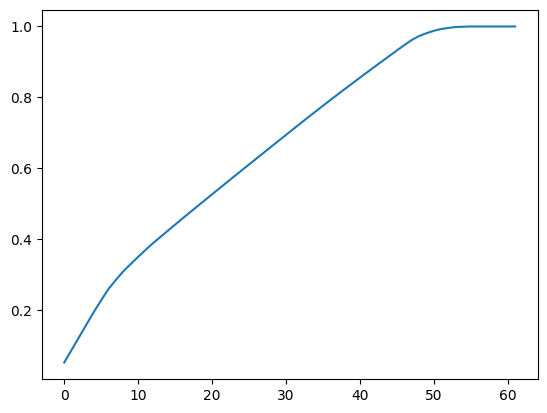

In [ ]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))

## Conclusion

PCA was applied to the Employee Attrition dataset after feature scaling.

The cumulative explained variance analysis showed that:

- Around 35 principal components retain approximately 80% of the information.
- Around 40 principal components retain approximately 90% of the information.
- Around 45 principal components retain approximately 95% of the information.

This indicates that the dataset contains information distributed across many features and cannot be effectively compressed into only 2 principal components without significant information loss.